<a href="https://colab.research.google.com/github/Yasmeen20110210/Final_Project/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

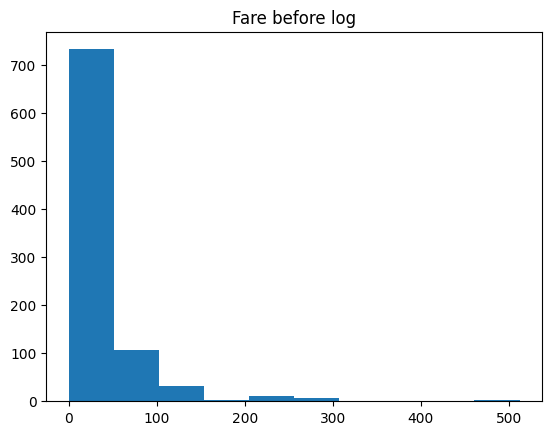

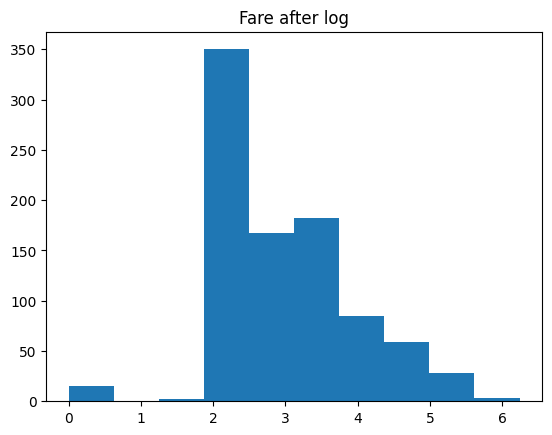

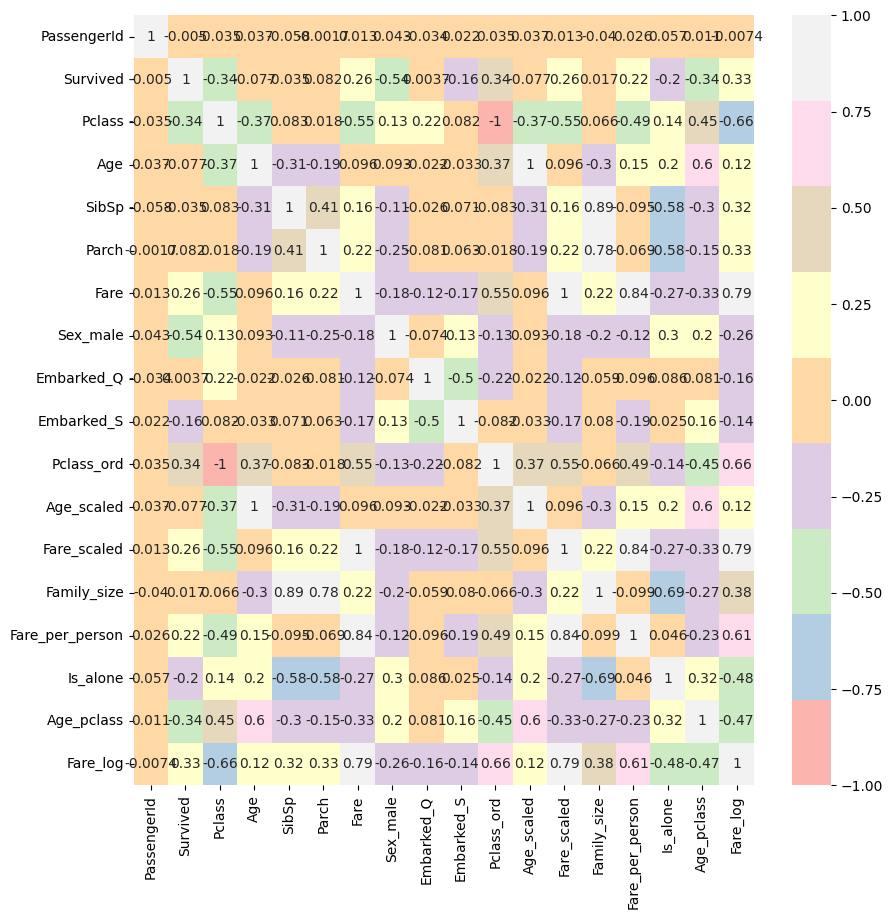

Dropped columns: ['Age_scaled', 'Fare_scaled']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Import everything I need


titanic =pd.read_csv("train.csv")
# Load the dataset
print("First 5 rows:", titanic.head())
# Show the first 5 rows
titanic = pd.get_dummies(titanic,columns=["Sex","Embarked"],drop_first=True)
# One hot encoding
pclass_map = {3:1,2:2,1:3}
titanic["Pclass_ord"] = titanic["Pclass"].map(pclass_map)
# Ordinal encoding
scaler = StandardScaler()
titanic[["Age_scaled","Fare_scaled"]] = scaler.fit_transform(titanic[["Age","Fare"]])
# Scaling on two numerical columns
titanic["Family_size"] = titanic["SibSp"] + titanic["Parch"] +1 # I added one here because the dataset doesn't count the person, only counts how many people are with the person
titanic["Fare_per_person"] = titanic["Fare"] / titanic["Family_size"]
titanic["Is_alone"] = (titanic["Family_size"] == 1).astype(int)
# Two new domain features
titanic["Age_pclass"] = titanic["Age"] * titanic["Pclass"]
# Interaction feature
plt.hist(titanic["Fare"])
plt.title("Fare before log")
plt.show()
# Hist plot to fare before log
titanic["Fare_log"] = np.log(titanic["Fare"] + 1) # I added one so the code won't show error
plt.hist(titanic["Fare_log"])
plt.title("Fare after log")
plt.show()
# Hist plot to fare after log
bins = [0,18,35,60,100]
labels = ["child","young","adult","senior"]
titanic["Age_group"] = pd.cut(titanic["Age"],bins,labels=labels)
# Binnig
corr = titanic.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap="Pastel1")
plt.show()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column]>0.95)]
titanic.drop(to_drop, axis=1, inplace=True)
print("Dropped columns:",to_drop)
# Correlation

titanic.to_csv("Titanic_features.csv", index=False)
# Save new file